# Friction sensitivity

**What this shows:** how to generate and run a set of SCHISM models that differ only
in their bottom friction, from one base configuration, and compare the results. This
is the pattern behind sensitivity tests and calibration.

**Prerequisites:** [Tutorial 5: Choosing model settings](../tutorial/05_model_settings.ipynb).

**You will learn:**

- how to build variants of a configuration
- how to run each in its own workspace
- how bottom friction changes the tide and the currents

**Data used:** `hgrid.gr3` and `tides/`. The runs need Docker and are skipped
without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "friction_sensitivity"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
ASPECT = 1 / np.cos(np.radians(32))

## 1. The base configuration and the variants

The tidal model of Tutorial 3, for two days. The variants differ in the bottom drag
coefficient, from smooth (0.001) to rough (0.01); 0.0025 is a common default for
sandy shelves. `SCHISMGrid` writes the value as `drag.gr3`.

In [2]:
data = SCHISMData(
    boundary_conditions=SCHISMDataBoundaryConditions(
        tidal_data=TidalDataset(
            tidal_database=DATA_DIR / "tides",
            tidal_model="TPXO9-perth",
            constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
            nodal_corrections=True,
        ),
        default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
    )
)
nml = NML(
    param=Param(
        core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 15, "ihfskip": 720},
        schout={"iof_hydro__1": 1, "iof_hydro__16": 1, "iof_hydro__26": 0},
    )
)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-03T00:00", interval="1h")

drag = {"smooth": 0.001, "default": 0.0025, "rough": 0.01}
runs = {}
for name, value in drag.items():
    grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=value)
    config = SCHISMConfig(grid=grid, data=data, nml=nml)
    runs[name] = ModelRun(run_id=name, period=period, output_dir=OUT_DIR, config=config)

Only the grid differs between the variants; the data and settings objects are shared.
Each `ModelRun` has its own `run_id`, so each gets its own workspace.

## 2. Generate and run

In [3]:


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


backend = DockerConfig(image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6)
results = {}
for name, modelrun in runs.items():
    workspace = Path(modelrun())
    if docker_available():
        modelrun.run(backend, workspace_dir=workspace)
    if run_completed(workspace):
        results[name] = xr.open_mfdataset(
            sorted((workspace / "outputs").glob("out2d_*.nc")),
            data_vars="minimal", coords="minimal", compat="override",
        )  # fmt: skip
print(f"Completed: {list(results)}")

Completed: ['smooth', 'default', 'rough']


## 3. Compare

Friction takes energy out of the tide as it crosses the shelf. Here the tide is small
and the shelf short, so the water level is the same to the eye in all three runs.
The currents change more: a rougher bed slows the fastest tidal currents, around the
islands, by up to about a fifth, and a smoother bed speeds them up a little. Where
currents and water levels matter more, on a macrotidal coast or in an estuary,
friction is one of the main calibration parameters.

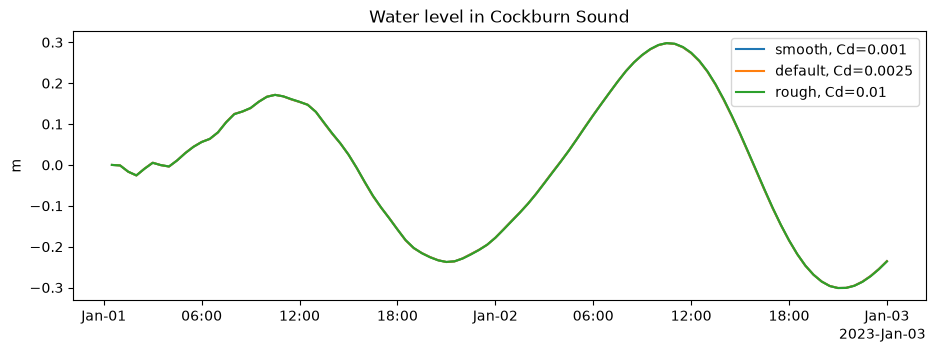

In [4]:
if len(results) == len(drag):
    out = results["default"]
    x, y = out.SCHISM_hgrid_node_x.values, out.SCHISM_hgrid_node_y.values
    node = np.argmin((x - 115.72) ** 2 + (y + 32.20) ** 2)  # Cockburn Sound
    fig, ax = plt.subplots(figsize=(11, 3.5))
    for name, result in results.items():
        result.elevation[:, node].plot(ax=ax, label=f"{name}, Cd={drag[name]}")
    ax.set(title="Water level in Cockburn Sound", ylabel="m", xlabel="")
    ax.legend()

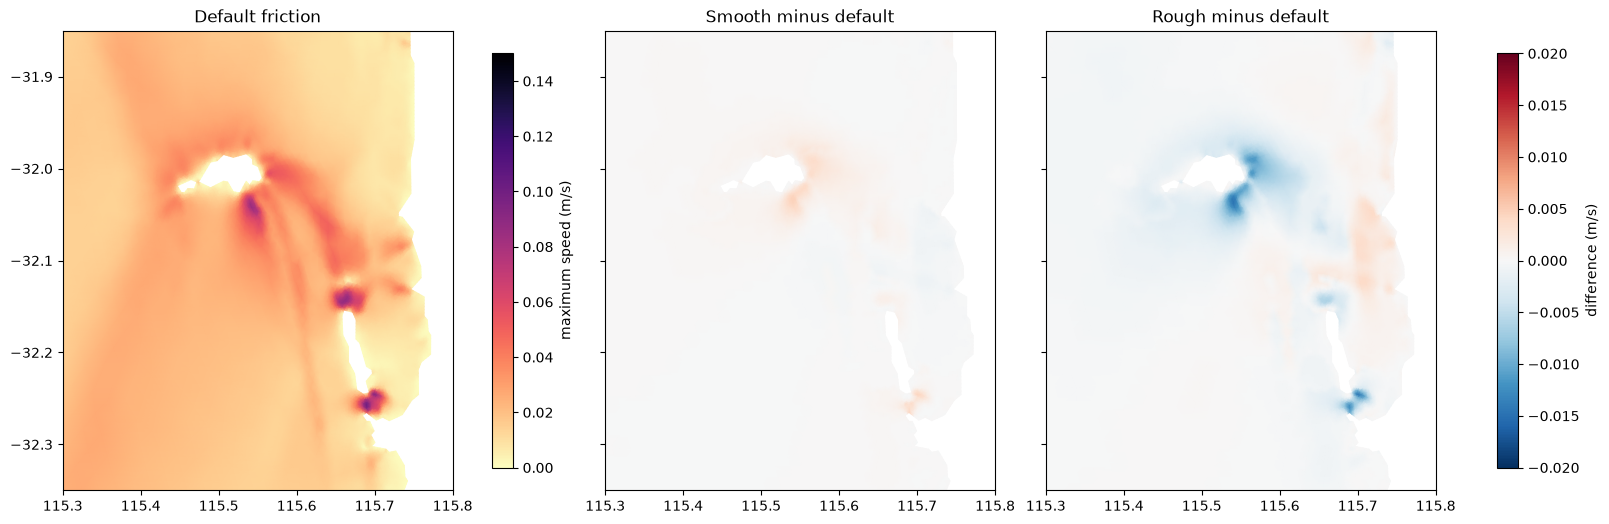

In [5]:
if len(results) == len(drag):
    triangulation = mtri.Triangulation(
        x, y, out.SCHISM_hgrid_face_nodes.values[:, :3] - 1
    )

    def max_speed(result: xr.Dataset) -> np.ndarray:
        day2 = result.sel(time=slice("2023-01-02", None))
        return np.hypot(day2.depthAverageVelX, day2.depthAverageVelY).max("time").values

    reference = max_speed(results["default"])
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True, layout="constrained")
    tpc = axes[0].tripcolor(
        triangulation, reference, cmap="magma_r", shading="gouraud", vmin=0, vmax=0.15
    )
    fig.colorbar(tpc, ax=axes[0], label="maximum speed (m/s)", shrink=0.7)
    axes[0].set(title="Default friction")
    for ax, name in zip(axes[1:], ["smooth", "rough"]):
        tpc = ax.tripcolor(
            triangulation, max_speed(results[name]) - reference, cmap="RdBu_r",
            shading="gouraud", vmin=-0.02, vmax=0.02,
        )  # fmt: skip
        ax.set(title=f"{name.capitalize()} minus default")
    fig.colorbar(tpc, ax=axes[1:], label="difference (m/s)", shrink=0.7)
    for ax in axes:
        ax.set(xlim=(115.3, 115.8), ylim=(-32.35, -31.85), aspect=ASPECT)

Which friction is right depends on the bed and should be decided against
measurements: tide gauges for the water level and current meters for the currents.

## Summary

- Build one configuration per variant, sharing the parts that do not change.
- Give each variant its own `run_id`, so the workspaces stay separate.
- Compare the results against a reference, and against observations when choosing.